# Actividad: Hibridación de Algoritmos de Optimización

**Nombre** Jhoffre Moreano Goyes  
**Combinación seleccionada:** GA + SA  
**Problema aplicado:** TSP con 8 ciudades  
**Lenguaje:** Python  
**Tipo de ejecución:** Secuencial  

Este notebook desarrolla la actividad completa solicitada:

1. Selección de hibridación.  
2. Implementación de algoritmos por separado.  
3. Aplicación a un problema reducido.  
4. Ejecución de cada algoritmo 25 veces.  
5. Registro de calidad de solución, tiempo de ejecución, convergencia y robustez.


## 1. Selección de hibridación

Para esta actividad se seleccionó la combinación **GA + SA**, que corresponde a:

- **GA:** Algoritmo Genético.
- **SA:** Recocido Simulado.

Esta hibridación fue seleccionada porque el Algoritmo Genético permite explorar varias soluciones posibles mediante una población inicial, selección, cruce y mutación. Luego, el Recocido Simulado mejora la solución obtenida realizando una búsqueda local controlada, aceptando en algunos casos soluciones peores para evitar quedar atrapado en óptimos locales.

En el caso de Jhoffre, esta combinación permite resolver un problema de rutas tipo **TSP**, buscando una ruta corta entre varias ciudades.


## 2. Importación de librerías

In [2]:
import random
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

In [3]:
import random
import math

# =========================
# PROBLEMA: TSP REDUCIDO
# =========================

ciudades = {
    "Riobamba": (0, 0),
    "Ambato": (2, 6),
    "Latacunga": (5, 9),
    "Quito": (8, 12),
    "Guaranda": (-3, 5),
    "Cuenca": (4, -6),
    "Loja": (7, -10),
    "Guayaquil": (-6, -4)
}

nombres_ciudades = list(ciudades.keys())

def calcular_distancia(ciudad1, ciudad2):
    x1, y1 = ciudades[ciudad1]
    x2, y2 = ciudades[ciudad2]
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def distancia_total(ruta):
    total = 0
    for i in range(len(ruta)):
        ciudad_actual = ruta[i]
        ciudad_siguiente = ruta[(i + 1) % len(ruta)]
        total += calcular_distancia(ciudad_actual, ciudad_siguiente)
    return total


# =========================
# ALGORITMO GENÉTICO - GA
# =========================

def crear_ruta_aleatoria():
    ruta = nombres_ciudades.copy()
    random.shuffle(ruta)
    return ruta

def crear_poblacion(tamano):
    return [crear_ruta_aleatoria() for _ in range(tamano)]

def seleccion(poblacion, cantidad):
    return sorted(poblacion, key=distancia_total)[:cantidad]

def cruce(padre1, padre2):
    inicio = random.randint(0, len(padre1) - 2)
    fin = random.randint(inicio + 1, len(padre1) - 1)

    hijo = [None] * len(padre1)
    hijo[inicio:fin] = padre1[inicio:fin]

    posicion = 0
    for ciudad in padre2:
        if ciudad not in hijo:
            while hijo[posicion] is not None:
                posicion += 1
            hijo[posicion] = ciudad

    return hijo

def mutacion(ruta, probabilidad=0.2):
    nueva_ruta = ruta.copy()

    if random.random() < probabilidad:
        i, j = random.sample(range(len(nueva_ruta)), 2)
        nueva_ruta[i], nueva_ruta[j] = nueva_ruta[j], nueva_ruta[i]

    return nueva_ruta

def algoritmo_genetico(tamano_poblacion=40, generaciones=100):
    poblacion = crear_poblacion(tamano_poblacion)

    for _ in range(generaciones):
        mejores = seleccion(poblacion, tamano_poblacion // 2)
        nueva_poblacion = mejores.copy()

        while len(nueva_poblacion) < tamano_poblacion:
            padre1, padre2 = random.sample(mejores, 2)
            hijo = cruce(padre1, padre2)
            hijo = mutacion(hijo)
            nueva_poblacion.append(hijo)

        poblacion = nueva_poblacion

    mejor_ruta = seleccion(poblacion, 1)[0]
    mejor_distancia = distancia_total(mejor_ruta)

    return mejor_ruta, mejor_distancia


# =========================
# RECOCIDO SIMULADO - SA
# =========================

def generar_vecino(ruta):
    vecino = ruta.copy()
    i, j = random.sample(range(len(vecino)), 2)
    vecino[i], vecino[j] = vecino[j], vecino[i]
    return vecino

def recocido_simulado(ruta_inicial=None, temperatura=100, enfriamiento=0.95, iteraciones=300):
    if ruta_inicial is None:
        ruta_actual = crear_ruta_aleatoria()
    else:
        ruta_actual = ruta_inicial.copy()

    mejor_ruta = ruta_actual.copy()

    for _ in range(iteraciones):
        vecino = generar_vecino(ruta_actual)

        distancia_actual = distancia_total(ruta_actual)
        distancia_vecino = distancia_total(vecino)

        diferencia = distancia_vecino - distancia_actual

        if diferencia < 0:
            ruta_actual = vecino
        else:
            probabilidad = math.exp(-diferencia / temperatura)

            if random.random() < probabilidad:
                ruta_actual = vecino

        if distancia_total(ruta_actual) < distancia_total(mejor_ruta):
            mejor_ruta = ruta_actual.copy()

        temperatura *= enfriamiento

        if temperatura < 0.001:
            temperatura = 0.001

    mejor_distancia = distancia_total(mejor_ruta)

    return mejor_ruta, mejor_distancia


# =========================
# HIBRIDACIÓN GA + SA
# =========================

def hibridacion_ga_sa():
    ruta_ga, distancia_ga = algoritmo_genetico()

    ruta_hibrida, distancia_hibrida = recocido_simulado(
        ruta_inicial=ruta_ga,
        temperatura=100,
        enfriamiento=0.95,
        iteraciones=300
    )

    return ruta_hibrida, distancia_hibrida


# =========================
# EJECUCIÓN DE PRUEBA
# =========================

ruta_ga, dist_ga = algoritmo_genetico()
print("Resultado Algoritmo Genético GA")
print("Ruta:", ruta_ga)
print("Distancia:", round(dist_ga, 2))

print("\n")

ruta_sa, dist_sa = recocido_simulado()
print("Resultado Recocido Simulado SA")
print("Ruta:", ruta_sa)
print("Distancia:", round(dist_sa, 2))

print("\n")

ruta_h, dist_h = hibridacion_ga_sa()
print("Resultado Hibridación GA + SA")
print("Ruta:", ruta_h)
print("Distancia:", round(dist_h, 2))

Resultado Algoritmo Genético GA
Ruta: ['Latacunga', 'Ambato', 'Guaranda', 'Riobamba', 'Guayaquil', 'Cuenca', 'Loja', 'Quito']
Distancia: 63.85


Resultado Recocido Simulado SA
Ruta: ['Guaranda', 'Guayaquil', 'Loja', 'Cuenca', 'Riobamba', 'Ambato', 'Latacunga', 'Quito']
Distancia: 63.86


Resultado Hibridación GA + SA
Ruta: ['Guayaquil', 'Riobamba', 'Guaranda', 'Ambato', 'Latacunga', 'Quito', 'Loja', 'Cuenca']
Distancia: 63.85


## 3. Aplicación a un problema: TSP con 8 ciudades

El problema del vendedor viajero, conocido como **TSP**, consiste en visitar todas las ciudades una sola vez y regresar al punto inicial, minimizando la distancia total del recorrido.

Para esta práctica se trabajará con 8 ciudades representadas mediante coordenadas en un plano.


In [6]:
# Coordenadas de ciudades
ciudades = {
    "Riobamba": (0, 0),
    "Ambato": (2, 6),
    "Latacunga": (5, 9),
    "Quito": (8, 12),
    "Guaranda": (-3, 5),
    "Cuenca": (4, -6),
    "Loja": (7, -10),
    "Guayaquil": (-6, -4)
}

nombres_ciudades = list(ciudades.keys())
coordenadas = np.array(list(ciudades.values()))

def calcular_distancia(ciudad1, ciudad2):
    x1, y1 = ciudades[ciudad1]
    x2, y2 = ciudades[ciudad2]
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def distancia_total(ruta):
    total = 0
    for i in range(len(ruta)):
        ciudad_actual = ruta[i]
        ciudad_siguiente = ruta[(i + 1) % len(ruta)]
        total += calcular_distancia(ciudad_actual, ciudad_siguiente)
    return total

# Mostrar una ruta de ejemplo
ruta_ejemplo = nombres_ciudades.copy()
print("Ruta ejemplo:", ruta_ejemplo)
print("Distancia total:", round(distancia_total(ruta_ejemplo), 2))

Ruta ejemplo: ['Riobamba', 'Ambato', 'Latacunga', 'Quito', 'Guaranda', 'Cuenca', 'Loja', 'Guayaquil']
Distancia total: 67.42


## 4. Visualización de las ciudades

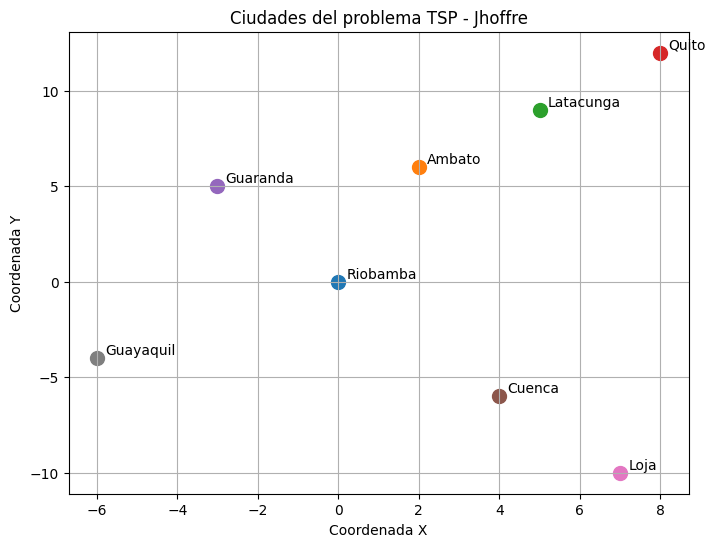

In [7]:
plt.figure(figsize=(8, 6))

for ciudad, (x, y) in ciudades.items():
    plt.scatter(x, y, s=100)
    plt.text(x + 0.2, y + 0.2, ciudad, fontsize=10)

plt.title("Ciudades del problema TSP - Jhoffre")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.grid(True)
plt.show()

## 5. Algoritmo Genético GA por separado

El **Algoritmo Genético** trabaja con una población de rutas. En cada generación selecciona las mejores rutas, realiza cruces entre ellas y aplica mutaciones para generar nuevas soluciones.


In [8]:
def crear_ruta_aleatoria():
    ruta = nombres_ciudades.copy()
    random.shuffle(ruta)
    return ruta

def crear_poblacion(tamano_poblacion):
    return [crear_ruta_aleatoria() for _ in range(tamano_poblacion)]

def seleccion(poblacion, cantidad):
    poblacion_ordenada = sorted(poblacion, key=distancia_total)
    return poblacion_ordenada[:cantidad]

def cruce(padre1, padre2):
    inicio = random.randint(0, len(padre1) - 2)
    fin = random.randint(inicio + 1, len(padre1) - 1)

    hijo = [None] * len(padre1)
    hijo[inicio:fin] = padre1[inicio:fin]

    posicion = 0
    for ciudad in padre2:
        if ciudad not in hijo:
            while hijo[posicion] is not None:
                posicion += 1
            hijo[posicion] = ciudad

    return hijo

def mutacion(ruta, probabilidad_mutacion=0.2):
    nueva_ruta = ruta.copy()
    if random.random() < probabilidad_mutacion:
        i, j = random.sample(range(len(nueva_ruta)), 2)
        nueva_ruta[i], nueva_ruta[j] = nueva_ruta[j], nueva_ruta[i]
    return nueva_ruta

def algoritmo_genetico(tamano_poblacion=40, generaciones=100):
    inicio_tiempo = time.time()

    poblacion = crear_poblacion(tamano_poblacion)
    convergencia = []

    for _ in range(generaciones):
        mejores = seleccion(poblacion, tamano_poblacion // 2)

        nueva_poblacion = mejores.copy()

        while len(nueva_poblacion) < tamano_poblacion:
            padre1, padre2 = random.sample(mejores, 2)
            hijo = cruce(padre1, padre2)
            hijo = mutacion(hijo)
            nueva_poblacion.append(hijo)

        poblacion = nueva_poblacion
        mejor_actual = seleccion(poblacion, 1)[0]
        convergencia.append(distancia_total(mejor_actual))

    mejor_ruta = seleccion(poblacion, 1)[0]
    mejor_distancia = distancia_total(mejor_ruta)
    tiempo = time.time() - inicio_tiempo

    return mejor_ruta, mejor_distancia, tiempo, convergencia

# Prueba individual del GA
ruta_ga, distancia_ga, tiempo_ga, conv_ga = algoritmo_genetico()
print("Mejor ruta GA:", ruta_ga)
print("Distancia GA:", round(distancia_ga, 2))
print("Tiempo GA:", round(tiempo_ga, 4), "segundos")

Mejor ruta GA: ['Cuenca', 'Loja', 'Quito', 'Latacunga', 'Ambato', 'Guaranda', 'Riobamba', 'Guayaquil']
Distancia GA: 63.85
Tiempo GA: 0.0782 segundos


## 6. Recocido Simulado SA por separado

El **Recocido Simulado** parte de una ruta inicial y genera rutas vecinas. Si una ruta vecina mejora la distancia, se acepta. Si no mejora, puede aceptarse con cierta probabilidad, dependiendo de la temperatura.


In [9]:
def generar_vecino(ruta):
    vecino = ruta.copy()
    i, j = random.sample(range(len(vecino)), 2)
    vecino[i], vecino[j] = vecino[j], vecino[i]
    return vecino

def recocido_simulado(temperatura_inicial=100, enfriamiento=0.95, iteraciones=300, ruta_inicial=None):
    inicio_tiempo = time.time()

    if ruta_inicial is None:
        ruta_actual = crear_ruta_aleatoria()
    else:
        ruta_actual = ruta_inicial.copy()

    mejor_ruta = ruta_actual.copy()
    temperatura = temperatura_inicial
    convergencia = []

    for _ in range(iteraciones):
        vecino = generar_vecino(ruta_actual)

        distancia_actual = distancia_total(ruta_actual)
        distancia_vecino = distancia_total(vecino)

        diferencia = distancia_vecino - distancia_actual

        if diferencia < 0:
            ruta_actual = vecino
        else:
            probabilidad = math.exp(-diferencia / temperatura)
            if random.random() < probabilidad:
                ruta_actual = vecino

        if distancia_total(ruta_actual) < distancia_total(mejor_ruta):
            mejor_ruta = ruta_actual.copy()

        convergencia.append(distancia_total(mejor_ruta))
        temperatura *= enfriamiento

        if temperatura < 0.001:
            temperatura = 0.001

    mejor_distancia = distancia_total(mejor_ruta)
    tiempo = time.time() - inicio_tiempo

    return mejor_ruta, mejor_distancia, tiempo, convergencia

# Prueba individual del SA
ruta_sa, distancia_sa, tiempo_sa, conv_sa = recocido_simulado()
print("Mejor ruta SA:", ruta_sa)
print("Distancia SA:", round(distancia_sa, 2))
print("Tiempo SA:", round(tiempo_sa, 4), "segundos")

Mejor ruta SA: ['Riobamba', 'Guaranda', 'Ambato', 'Latacunga', 'Quito', 'Loja', 'Cuenca', 'Guayaquil']
Distancia SA: 63.85
Tiempo SA: 0.0055 segundos


## 7. Hibridación GA + SA

La hibridación se realiza de forma secuencial:

1. Primero se ejecuta el **Algoritmo Genético** para obtener una buena ruta inicial.
2. Luego esa ruta se utiliza como entrada para el **Recocido Simulado**.
3. El objetivo es mejorar la ruta generada por GA mediante búsqueda local con SA.


In [10]:
def hibridacion_ga_sa():
    inicio_tiempo = time.time()

    ruta_ga, distancia_ga, tiempo_ga, conv_ga = algoritmo_genetico(
        tamano_poblacion=40,
        generaciones=100
    )

    ruta_hibrida, distancia_hibrida, tiempo_sa, conv_sa = recocido_simulado(
        temperatura_inicial=100,
        enfriamiento=0.95,
        iteraciones=300,
        ruta_inicial=ruta_ga
    )

    tiempo_total = time.time() - inicio_tiempo
    convergencia_total = conv_ga + conv_sa

    return ruta_hibrida, distancia_hibrida, tiempo_total, convergencia_total

# Prueba individual del híbrido
ruta_h, distancia_h, tiempo_h, conv_h = hibridacion_ga_sa()
print("Mejor ruta híbrida GA + SA:", ruta_h)
print("Distancia híbrida:", round(distancia_h, 2))
print("Tiempo híbrido:", round(tiempo_h, 4), "segundos")

Mejor ruta híbrida GA + SA: ['Guayaquil', 'Riobamba', 'Guaranda', 'Ambato', 'Latacunga', 'Quito', 'Loja', 'Cuenca']
Distancia híbrida: 63.85
Tiempo híbrido: 0.0437 segundos


## 8. Función para graficar rutas

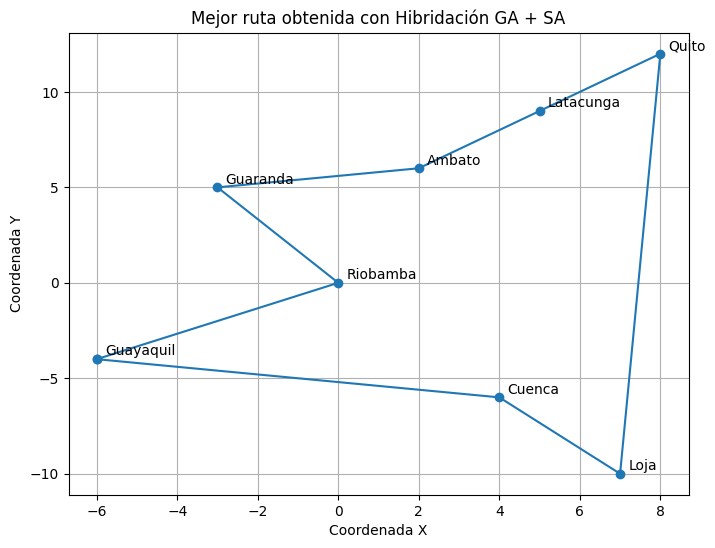

In [11]:
def graficar_ruta(ruta, titulo):
    plt.figure(figsize=(8, 6))

    x = [ciudades[ciudad][0] for ciudad in ruta] + [ciudades[ruta[0]][0]]
    y = [ciudades[ciudad][1] for ciudad in ruta] + [ciudades[ruta[0]][1]]

    plt.plot(x, y, marker="o")

    for ciudad, (cx, cy) in ciudades.items():
        plt.text(cx + 0.2, cy + 0.2, ciudad, fontsize=10)

    plt.title(titulo)
    plt.xlabel("Coordenada X")
    plt.ylabel("Coordenada Y")
    plt.grid(True)
    plt.show()

graficar_ruta(ruta_h, "Mejor ruta obtenida con Hibridación GA + SA")

## 9. Ejecución y registro de resultados

Se ejecutará cada algoritmo **25 veces**, registrando:

- Calidad de solución: distancia total de la ruta.
- Tiempo de ejecución.
- Convergencia.
- Robustez: estabilidad de los resultados mediante desviación estándar.


In [12]:
def ejecutar_experimentos(veces=25):
    resultados = []
    convergencias = {
        "GA": [],
        "SA": [],
        "GA+SA": []
    }

    for i in range(1, veces + 1):
        ruta_ga, dist_ga, tiempo_ga, conv_ga = algoritmo_genetico()
        resultados.append(["GA", i, dist_ga, tiempo_ga, ruta_ga])
        convergencias["GA"].append(conv_ga)

        ruta_sa, dist_sa, tiempo_sa, conv_sa = recocido_simulado()
        resultados.append(["SA", i, dist_sa, tiempo_sa, ruta_sa])
        convergencias["SA"].append(conv_sa)

        ruta_h, dist_h, tiempo_h, conv_h = hibridacion_ga_sa()
        resultados.append(["GA+SA", i, dist_h, tiempo_h, ruta_h])
        convergencias["GA+SA"].append(conv_h)

    df_resultados = pd.DataFrame(
        resultados,
        columns=["Algoritmo", "Ejecución", "Distancia", "Tiempo", "Ruta"]
    )

    return df_resultados, convergencias

df_resultados, convergencias = ejecutar_experimentos(25)

df_resultados.head(10)

,Algoritmo,Ejecución,Distancia,Tiempo,Ruta
0,GA,1,63.847110,0.063339,"[Guaranda, Ambato, Latacunga, Quito, Loja, Cue..."
1,SA,1,63.847110,0.009531,"[Riobamba, Guaranda, Ambato, Latacunga, Quito,..."
2,GA+SA,1,63.847110,0.072091,"[Loja, Cuenca, Guayaquil, Riobamba, Guaranda, ..."
3,GA,2,63.863998,0.066140,"[Riobamba, Cuenca, Loja, Guayaquil, Guaranda, ..."
4,SA,2,63.863998,0.009113,"[Loja, Cuenca, Riobamba, Ambato, Latacunga, Qu..."
5,GA+SA,2,63.847110,0.074477,"[Loja, Quito, Latacunga, Ambato, Guaranda, Rio..."
6,GA,3,63.863998,0.062308,"[Guaranda, Quito, Latacunga, Ambato, Riobamba,..."
7,SA,3,63.863998,0.010364,"[Loja, Cuenca, Riobamba, Ambato, Latacunga, Qu..."
8,GA+SA,3,63.863998,0.078485,"[Guaranda, Quito, Latacunga, Ambato, Riobamba,..."
9,GA,4,63.847110,0.065965,"[Guayaquil, Riobamba, Guaranda, Ambato, Latacu..."


## 10. Tabla resumen de resultados

In [13]:
resumen = df_resultados.groupby("Algoritmo").agg(
    Mejor_Distancia=("Distancia", "min"),
    Peor_Distancia=("Distancia", "max"),
    Promedio_Distancia=("Distancia", "mean"),
    Desviacion_Distancia=("Distancia", "std"),
    Promedio_Tiempo=("Tiempo", "mean")
).reset_index()

resumen

,Algoritmo,Mejor_Distancia,Peor_Distancia,Promedio_Distancia,Desviacion_Distancia,Promedio_Tiempo
0,GA,63.84711,63.863998,63.855892,0.008611,0.058114
1,GA+SA,63.84711,63.863998,63.850488,0.006895,0.066651
2,SA,63.84711,63.863998,63.853190,0.008273,0.008566


## 11. Mejor resultado obtenido por cada algoritmo

In [14]:
mejores = df_resultados.loc[df_resultados.groupby("Algoritmo")["Distancia"].idxmin()]
mejores[["Algoritmo", "Ejecución", "Distancia", "Tiempo", "Ruta"]]

,Algoritmo,Ejecución,Distancia,Tiempo,Ruta
0,GA,1,63.84711,0.063339,"[Guaranda, Ambato, Latacunga, Quito, Loja, Cue..."
5,GA+SA,2,63.84711,0.074477,"[Loja, Quito, Latacunga, Ambato, Guaranda, Rio..."
1,SA,1,63.84711,0.009531,"[Riobamba, Guaranda, Ambato, Latacunga, Quito,..."


## 12. Gráfica comparativa de calidad de solución

Mientras menor sea la distancia, mejor es la solución.


<Figure size 800x500 with 0 Axes>

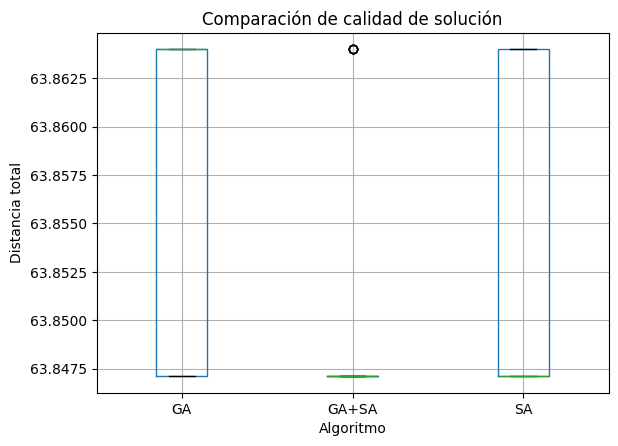

In [15]:
plt.figure(figsize=(8, 5))
df_resultados.boxplot(column="Distancia", by="Algoritmo")
plt.title("Comparación de calidad de solución")
plt.suptitle("")
plt.xlabel("Algoritmo")
plt.ylabel("Distancia total")
plt.grid(True)
plt.show()

## 13. Gráfica comparativa de tiempo de ejecución

<Figure size 800x500 with 0 Axes>

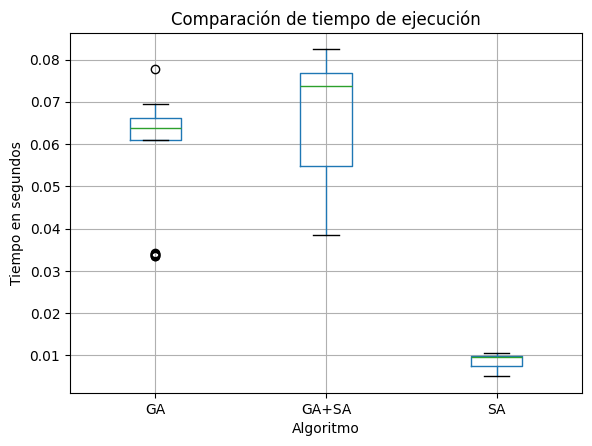

In [16]:
plt.figure(figsize=(8, 5))
df_resultados.boxplot(column="Tiempo", by="Algoritmo")
plt.title("Comparación de tiempo de ejecución")
plt.suptitle("")
plt.xlabel("Algoritmo")
plt.ylabel("Tiempo en segundos")
plt.grid(True)
plt.show()

## 14. Convergencia promedio

La convergencia permite observar cómo mejora la solución durante las iteraciones.


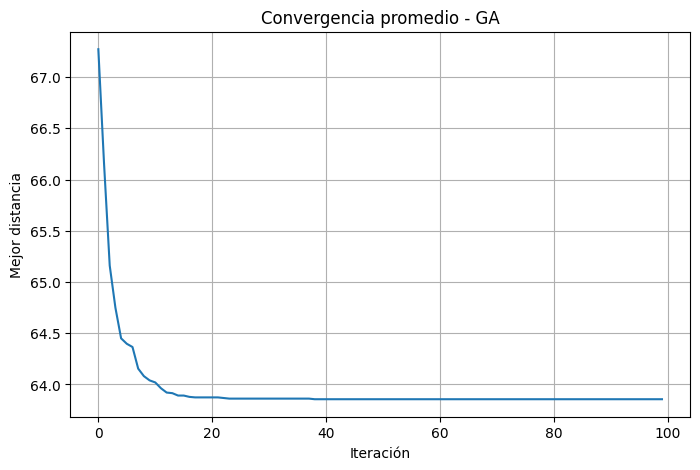

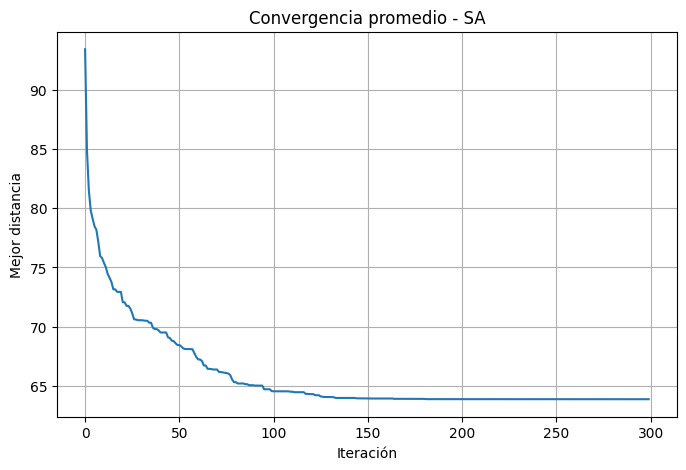

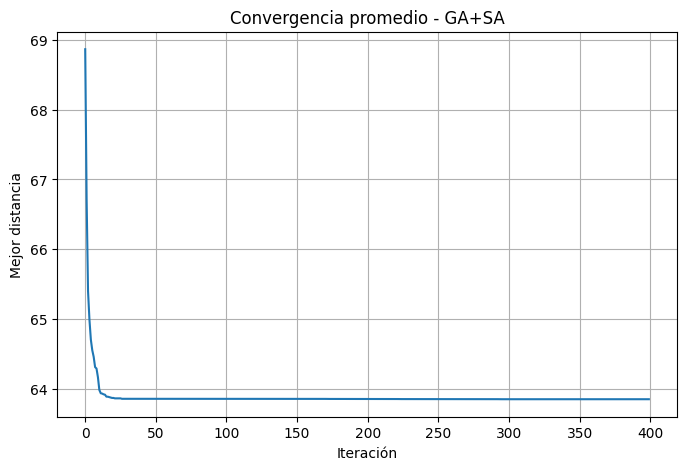

In [17]:
def promedio_convergencia(lista_convergencias):
    longitud_minima = min(len(c) for c in lista_convergencias)
    recortadas = [c[:longitud_minima] for c in lista_convergencias]
    return np.mean(recortadas, axis=0)

for algoritmo, lista in convergencias.items():
    promedio = promedio_convergencia(lista)
    plt.figure(figsize=(8, 5))
    plt.plot(promedio)
    plt.title(f"Convergencia promedio - {algoritmo}")
    plt.xlabel("Iteración")
    plt.ylabel("Mejor distancia")
    plt.grid(True)
    plt.show()

## 15. Robustez de los algoritmos

La robustez se analiza mediante la desviación estándar de las distancias obtenidas. Una desviación estándar menor indica que el algoritmo produce resultados más estables entre ejecuciones.


In [18]:
for _, fila in resumen.iterrows():
    print("Algoritmo:", fila["Algoritmo"])
    print("Mejor distancia:", round(fila["Mejor_Distancia"], 2))
    print("Promedio distancia:", round(fila["Promedio_Distancia"], 2))
    print("Desviación estándar:", round(fila["Desviacion_Distancia"], 4))
    print("Promedio tiempo:", round(fila["Promedio_Tiempo"], 6), "segundos")
    print("-" * 50)

Algoritmo: GA
Mejor distancia: 63.85
Promedio distancia: 63.86
Desviación estándar: 0.0086
Promedio tiempo: 0.058114 segundos
--------------------------------------------------
Algoritmo: GA+SA
Mejor distancia: 63.85
Promedio distancia: 63.85
Desviación estándar: 0.0069
Promedio tiempo: 0.066651 segundos
--------------------------------------------------
Algoritmo: SA
Mejor distancia: 63.85
Promedio distancia: 63.85
Desviación estándar: 0.0083
Promedio tiempo: 0.008566 segundos
--------------------------------------------------


## 16. Interpretación de resultados


A partir de las **25 ejecuciones** realizadas para cada algoritmo, se evaluaron cuatro criterios principales: **calidad de la solución**, **tiempo de ejecución**, **convergencia** y **robustez**.

Los resultados muestran que los tres enfoques alcanzaron una **mejor distancia de 63.85**, lo que indica que tanto el Algoritmo Genético (GA), el Recocido Simulado (SA) y la hibridación **GA + SA** fueron capaces de encontrar soluciones de calidad similar para el problema TSP planteado.

Al analizar el **promedio de las distancias**, el algoritmo **GA + SA** obtuvo un valor de **63.85**, ligeramente mejor que el promedio obtenido por **GA (63.86)** y equivalente al alcanzado por **SA (63.85)**. Esto evidencia que la combinación de ambos algoritmos mantiene una calidad de solución consistente a lo largo de las diferentes ejecuciones.

Respecto al **tiempo de ejecución**, el **Recocido Simulado (SA)** presentó el mejor desempeño, con un tiempo promedio de **0.008566 segundos**, siendo considerablemente más rápido que **GA (0.058114 segundos)** y que la hibridación **GA + SA (0.066651 segundos)**. Este comportamiento era esperado, ya que SA trabaja sobre una única solución, mientras que GA y el método híbrido requieren procesar poblaciones y realizar operaciones adicionales de optimización.

En cuanto a la **robustez**, evaluada mediante la desviación estándar de las distancias obtenidas, la hibridación **GA + SA** registró el menor valor (**0.0069**), seguida por **SA (0.0083)** y **GA (0.0086)**. Una desviación estándar menor indica que el algoritmo genera resultados más estables y consistentes entre las diferentes ejecuciones, lo que demuestra que el enfoque híbrido ofrece una mayor confiabilidad.

En conclusión, aunque la hibridación **GA + SA** requiere un mayor tiempo de procesamiento que el algoritmo SA, proporciona una **mayor estabilidad en los resultados** y mantiene una excelente calidad de solución. Por su parte, **SA** destaca por su rapidez de ejecución, mientras que **GA** ofrece un buen equilibrio entre exploración del espacio de búsqueda y calidad de las soluciones. Para este problema reducido del TSP, la hibridación **GA + SA** constituye la alternativa más robusta, ya que combina la capacidad exploratoria del Algoritmo Genético con el refinamiento local del Recocido Simulado, obteniendo soluciones de alta calidad con un comportamiento más consistente entre ejecuciones.

## 17. Conclusiones

1. La hibridación **GA + SA** es adecuada para resolver un problema TSP reducido, porque combina exploración global y mejora local.

2. El Algoritmo Genético genera soluciones iniciales de buena calidad, mientras que el Recocido Simulado permite refinar la ruta final.

3. Al ejecutar los algoritmos 25 veces, se puede comparar la robustez mediante la desviación estándar, el tiempo promedio y la calidad de solución.

4. Para el caso personalizado de **Jhoffre**, la mejor alternativa es analizar la tabla resumen y seleccionar el algoritmo con menor distancia promedio y menor desviación estándar.
